In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames
from frame_renderer import init_worker, render_phase_angle_histogram

filenames = ['particles1.txt', 'particles2.txt', 'particles3.txt', 'particles4.txt']

datasets = []
# Read particle data
for file in filenames:
    
    Np_seq, time, r_dust, data_p = read_particle_frames(file)
    dataset = {}
    dataset['Np_seq'] = Np_seq
    dataset['time'] = time
    dataset['r_dust'] = r_dust
    dataset['data_p'] = data_p

    datasets.append(dataset)

num_datasets = len(datasets)

processing completed!
processing completed!
processing completed!
processing completed!


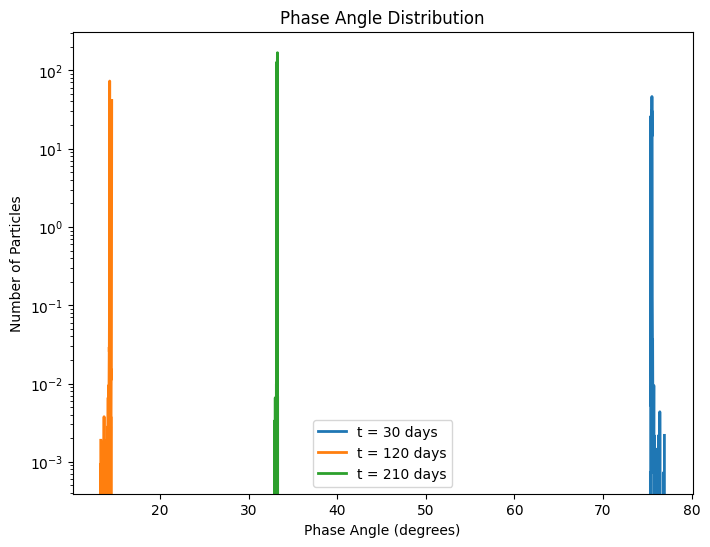

In [3]:
daylist = [30,120,210]

fig, ax = plt.subplots(figsize=(8, 6))

for day in daylist:
    target_seconds = day*86400

    # combine datasets of all sizes
    pos_dust_allsize = []
    for i in range(num_datasets):
        # get the frame index at the time
        t_idx = np.searchsorted(datasets[i]['time'], target_seconds, side="left")
        
        # position vectors
        p_t = datasets[i]['data_p'][t_idx]
        pos_dust_allsize.append(p_t[4:,1:4])
        if i==3:  #either average the position of sun and earth across datasets, or interpolate position of dusts to a certain moment
            pos_sun = p_t[2,1:4]
            pos_earth = p_t[3,1:4]
    
    pos_dust_allsize = np.vstack(pos_dust_allsize)
    
    # Compute vectors
    vec_sun = pos_sun - pos_dust_allsize  # Vectors from Sun to dust particles
    vec_earth = pos_earth - pos_dust_allsize  # Vectors from Earth to dust particles
    
    # Compute norms
    norm_sun = np.linalg.norm(vec_sun, axis=1)  # Magnitudes of Sun vectors
    norm_earth = np.linalg.norm(vec_earth, axis=1)  # Magnitudes of Earth vectors
    
    # Compute dot products
    dot_product = np.einsum('ij,ij->i', vec_sun, vec_earth)  # Dot product of Sun and Earth vectors
    
    # Compute phase angles
    cos_phase_angle = dot_product / (norm_sun * norm_earth)  # Cosine of phase angle
    phase_angle = np.arccos(np.clip(cos_phase_angle, -1.0, 1.0))  # Phase angle in radians
    phase_angle_deg = np.degrees(phase_angle)
    
    # Compute histogram of phase angles
    counts, bin_edges = np.histogram(phase_angle_deg, bins=200, density=True)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    
    # plot distribution of phase angles
    ax.plot(bin_centers, counts, lw=2, label=f't = {day} days')
    #plt.bar(bin_centers, counts, width=bin_edges[1]-bin_edges[0])

ax.set_yscale('log')
ax.set_xlabel('Phase Angle (degrees)')
ax.set_ylabel('Number of Particles')
ax.set_title('Phase Angle Distribution')
ax.legend()

# Save the PNG image
figname = "phase_angle_allsize.png"
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)